# 2D Polynomial Sky Subtraction — JWST MIRI i2d Mosaics

Removes residual large-scale background gradient from Stage 3 mosaics.

## 1. Configuration

In [1]:
# ═══════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════

# ─── Target ───────────────────────────────────────────────
FILT           = 'F2100W'
BASE_DIR       = '/Users/melyajou/SMC_GO5952/miri'

# ─── Input / Output ──────────────────────────────────────
stage3         = f'{BASE_DIR}/{FILT}/stage3'
INPUT_FILE     = f'{stage3}/miri_{FILT}_final_i2d.fits'
OUTPUT_FILE    = None    # auto: *_skysub.fits
SEGM_FILE      = f'{stage3}/miri_{FILT}_final_segm.fits'

# ─── Clark background (F2100W only) ──────────────────────
BKG_BASE       = f'{BASE_DIR}/{FILT}/MAST_2026-03-12T1713/JWST'

# ─── Sky subtraction parameters ──────────────────────────
POLY_DEGREE    = 2       # 2 = quadratic (6 terms)
SIGMA_UPPER    = 1.7     # sigma clipping threshold — tune per filter
GROW_NPIX      = 10      # mask dilation (pixels) — tune per filter
EDGE_CROP      = 50      # mask mosaic edges (pixels)

# ─── Figures ─────────────────────────────────────────────
CMAP           = 'afmhot'
FIG_DPI        = 200
fig_dir        = f'{BASE_DIR}/{FILT}/figures'

import os
os.makedirs(fig_dir, exist_ok=True)


## 2. Setup

In [2]:
# ═══════════════════════════════════════════════════════════
# SETUP
# ═══════════════════════════════════════════════════════════
import sys, os, glob
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.visualization import simple_norm
from scipy.ndimage import binary_erosion

sys.path.insert(0, '..')
from pipeline_utils import *
from skysub_utils import *

## 3. Load and inspect

In [3]:
# ═══════════════════════════════════════════════════════════
# Load and inspect
# ═══════════════════════════════════════════════════════════
data, header = load_i2d(INPUT_FILE)
print(f'{FILT}: {data.shape}')

F2100W: (1184, 1794)


## 4. Source masking

In [4]:
# ═══════════════════════════════════════════════════════════
# Source masking
# ═══════════════════════════════════════════════════════════
# Mask mosaic edges — the mosaic has irregular borders from dithering.
# binary_dilation (in make_source_mask): GROWS the source mask outward
# to catch faint wings around bright sources  using grow_npix
# binary_erosion shrinks any arbitrary shape inward by EDGE_CROP pixels,
# which correctly identifies the border strip regardless of the mosaic geometry.
mask, mean_bg, std_bg = make_source_mask(
    data, segm_file=SEGM_FILE, nsigma=SIGMA_UPPER,
    grow_npix=GROW_NPIX, edge_crop=EDGE_CROP)

  Segmentation map: 32 sources, 235773 pixels (11.1%)


  Background stats: mean = 5.8840, std = 0.7988
  Sigma clip (>1.7σ): 538641 additional pixels


  Grew mask by 10 px: 535271 additional pixels


  Edge crop (50 px): 283733 additional pixels masked
  Final mask: 1648137/2124096 pixels (77.6%)


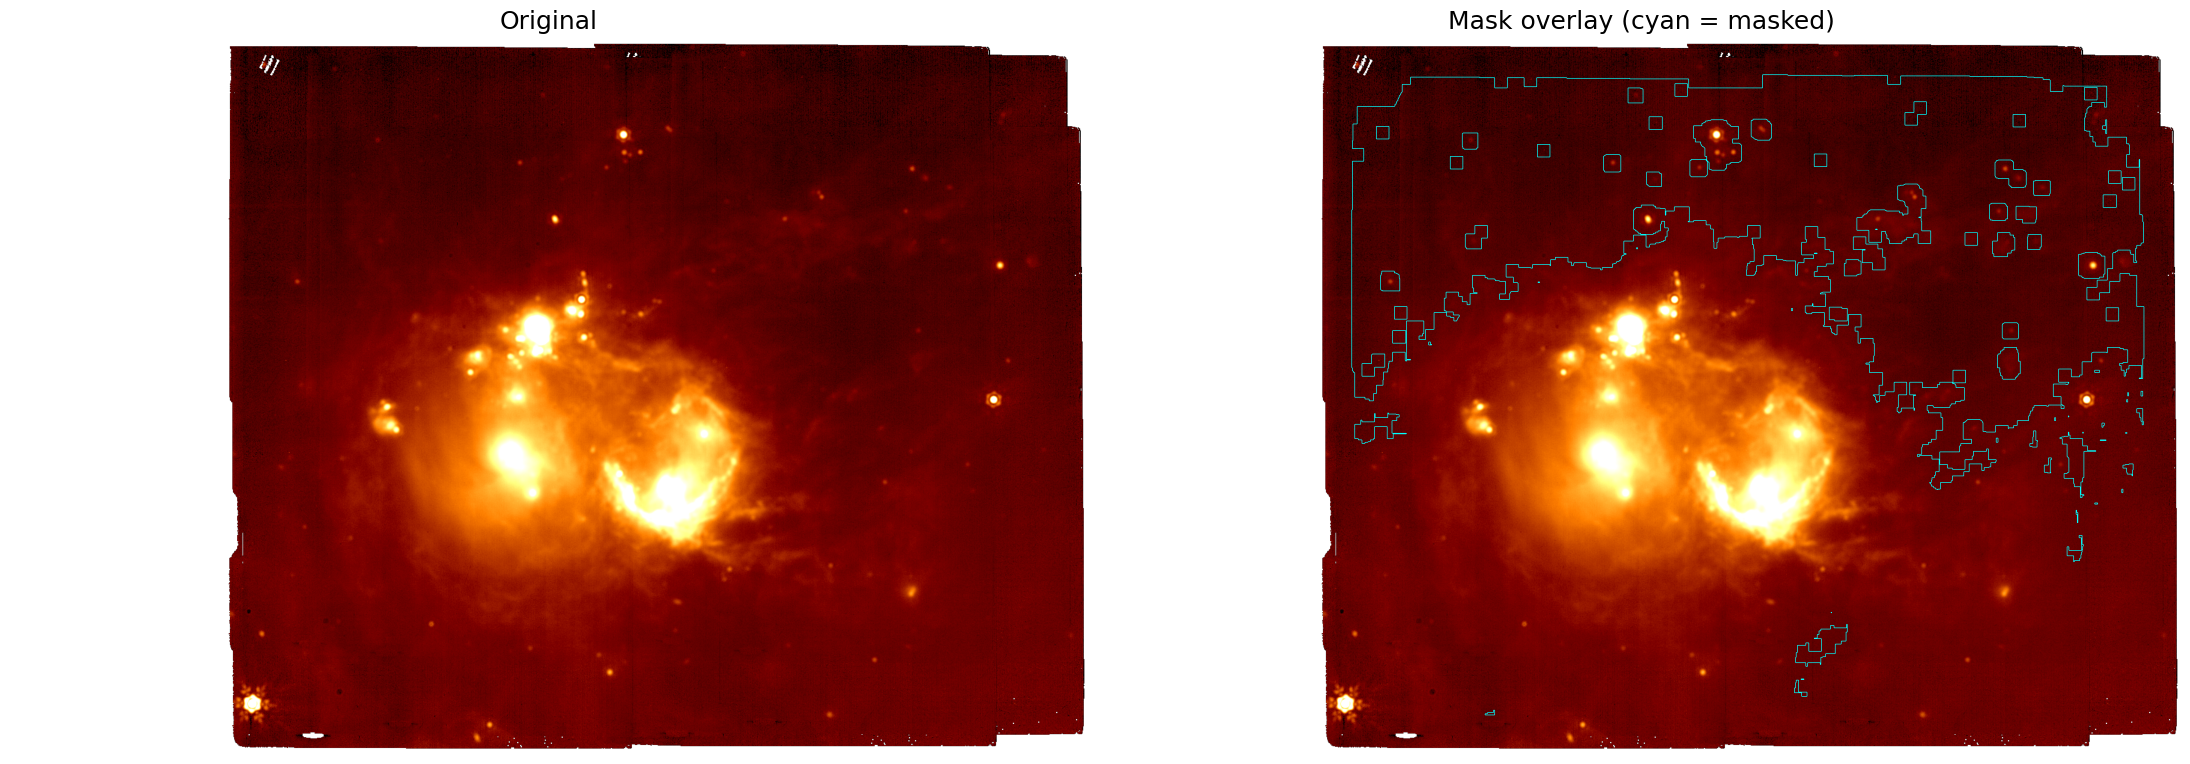

In [5]:
plot_mask_overlay(data, mask, FILT, cmap=CMAP, fig_dir=fig_dir, dpi=FIG_DPI)

## 5. Fit 2D polynomial

In [6]:
bg_model, coeffs = fit_2d_polynomial(data, mask, degree=POLY_DEGREE)

  Polynomial degree 2: 6 terms
  Fitting to 475959 unmasked pixels
  Coefficients:
    x^0 * y^0: 6.148171e+00
    x^1 * y^0: 7.520147e-02
    x^2 * y^0: -6.298910e-01
    x^0 * y^1: -8.564875e-01
    x^1 * y^1: 2.453529e-01
    x^0 * y^2: -4.544958e-01
  Residuals (unmasked): mean = 1.801948e-15, std = 4.366882e-01


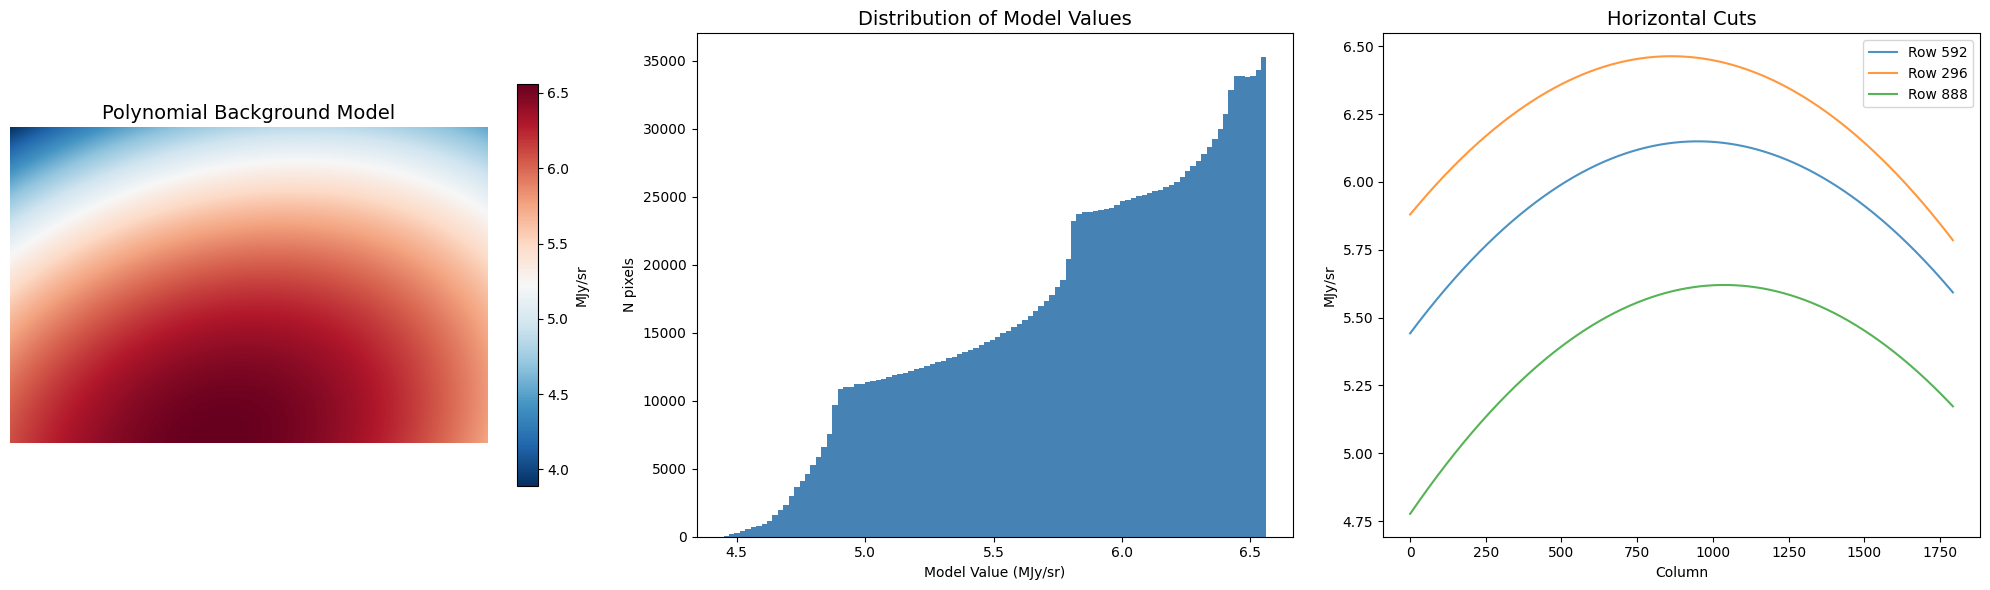

In [7]:
plot_bg_model(data, bg_model, FILT, fig_dir=fig_dir, dpi=FIG_DPI)

## 6. Subtract

In [8]:
data_sub = data - bg_model
data_sub[np.isnan(data)] = np.nan

good_sub = ~np.isnan(data_sub) & ~mask
print(f'Background after subtraction:')
print(f'  mean = {np.nanmean(data_sub[good_sub]):.6e}')
print(f'  std  = {np.nanstd(data_sub[good_sub]):.3f} MJy/sr')

Background after subtraction:
  mean = 1.801948e-15
  std  = 0.437 MJy/sr


## 7. Before / After

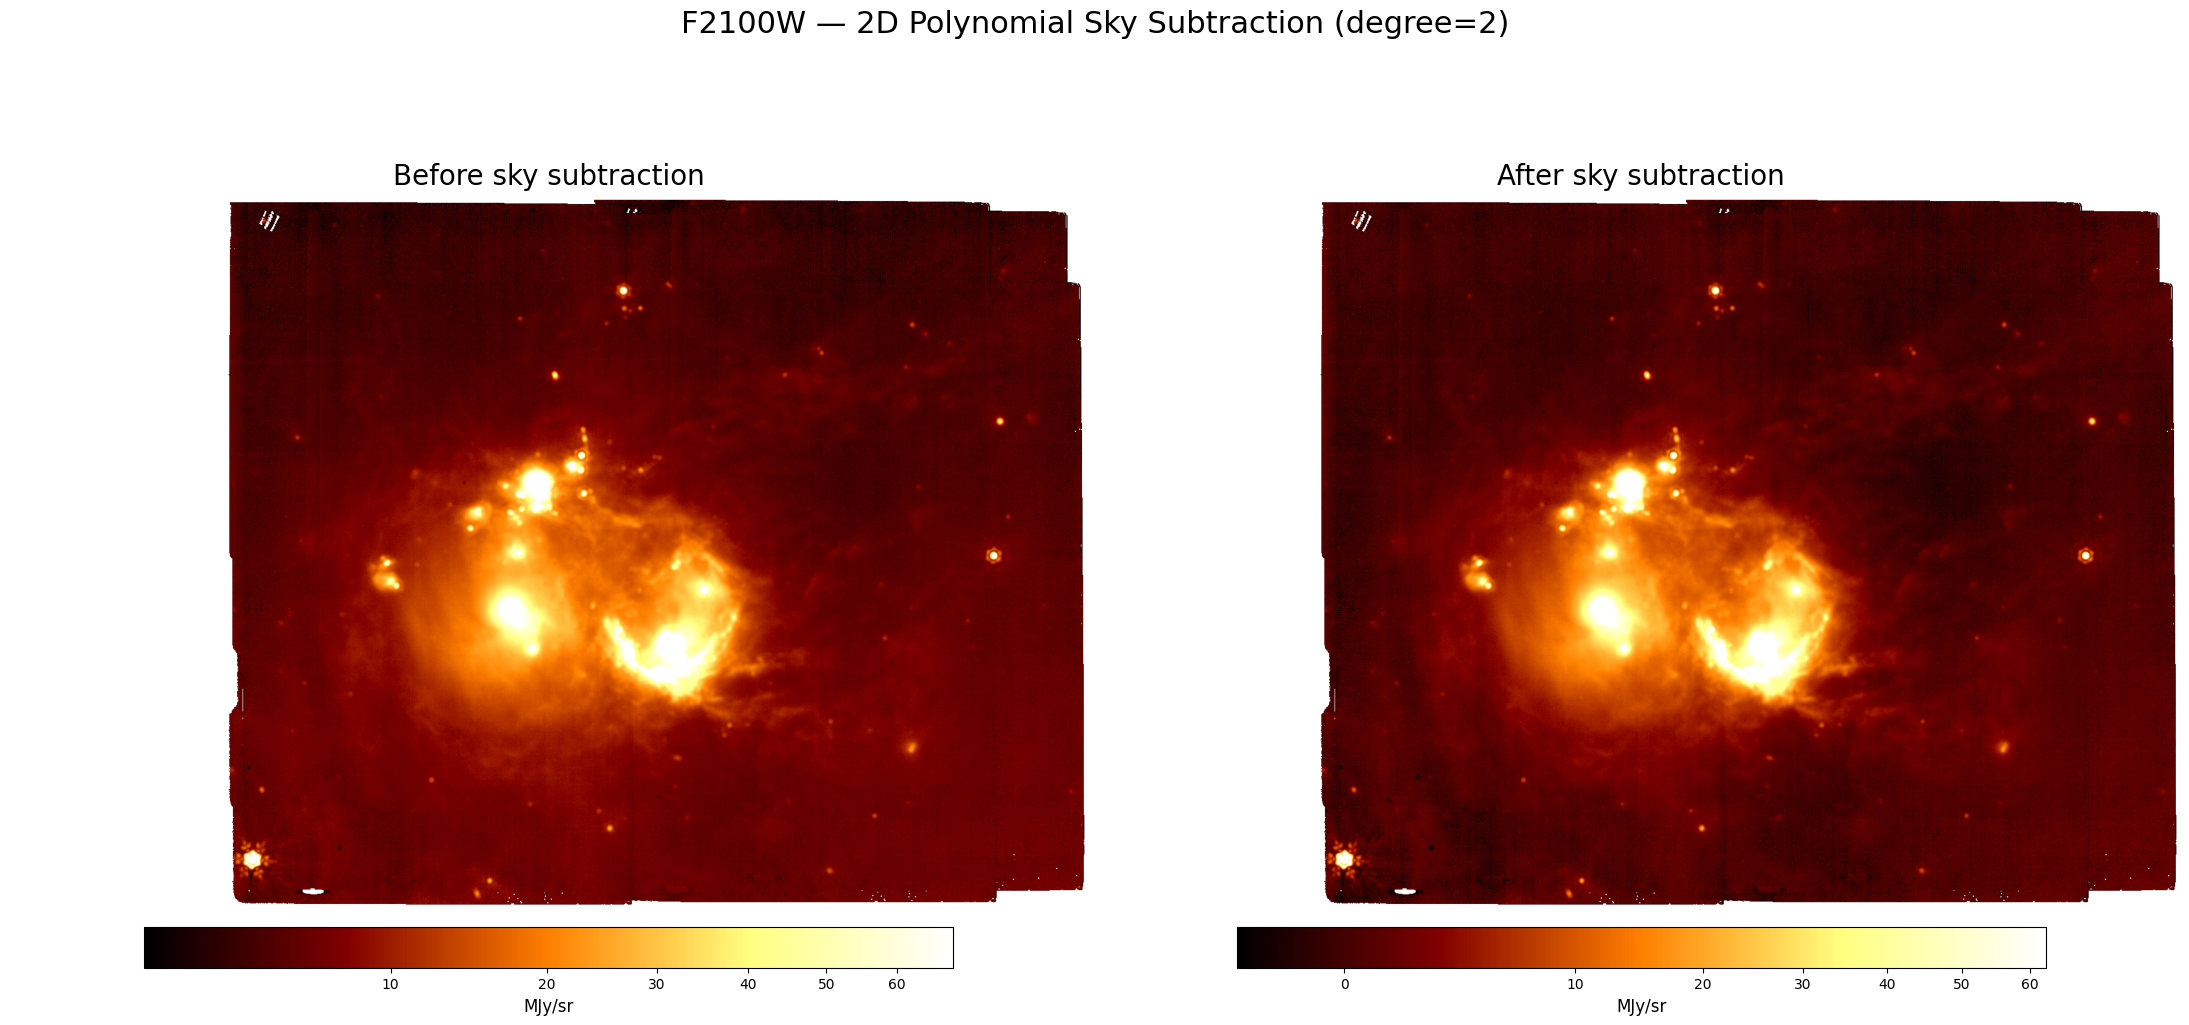

In [9]:
plot_before_after(data, data_sub, FILT, poly_degree=POLY_DEGREE,
                  cmap=CMAP, fig_dir=fig_dir, dpi=FIG_DPI)

## 8. Background histogram

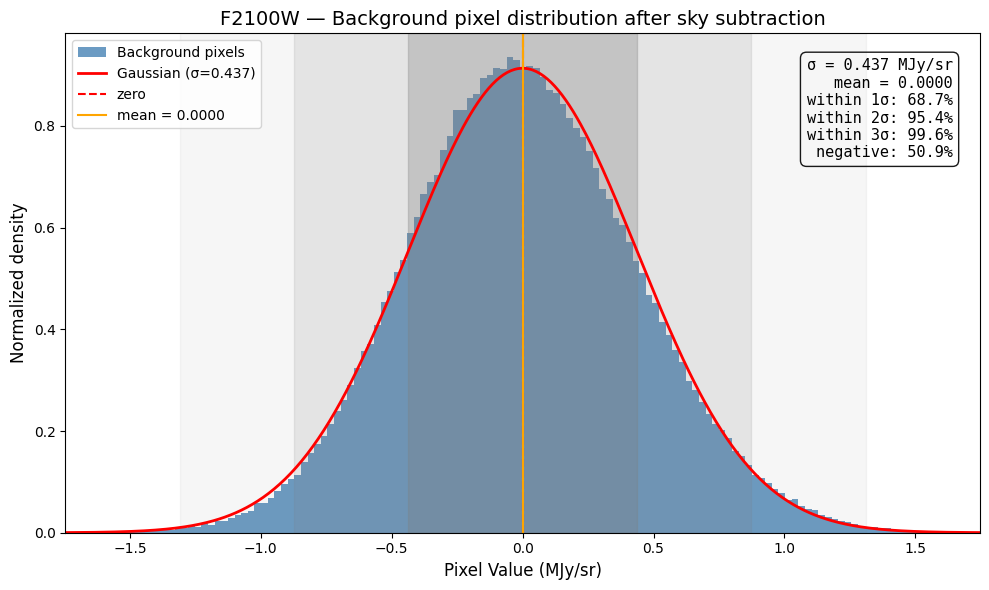

Gaussian expectation: 68.3% within 1σ, 95.4% within 2σ, 99.7% within 3σ
Our data:            68.7% within 1σ, 95.4% within 2σ, 99.6% within 3σ


In [10]:
plot_background_histogram(data_sub, good_sub, FILT, fig_dir=fig_dir, dpi=FIG_DPI)

## 9. Save

In [11]:
# Save
OUTPUT_FILE = save_skysub(INPUT_FILE, data_sub, bg_model, mask, header,
                          POLY_DEGREE, SIGMA_UPPER, GROW_NPIX, SEGM_FILE)

Saved: /Users/melyajou/SMC_GO5952/miri/F2100W/stage3/miri_F2100W_final_i2d_skysub.fits


## 10. Uncertainties

In [12]:
bkg_cals = sorted(glob.glob(f'{BKG_BASE}/jw03429*/jw*_cal.fits'))
pixel_noise, bkg_uncertainty, poly_bias = compute_uncertainties(
    data_sub, good_sub, bkg_cals=bkg_cals)


Pixel noise (random):          0.437 MJy/sr
Background level (systematic): 0.262 MJy/sr
Polynomial bias (systematic):  0.009 MJy/sr


## 11. Summary

In [13]:
print_summary(FILT, data_sub, good_sub, pixel_noise, bkg_uncertainty, poly_bias,
              POLY_DEGREE, SIGMA_UPPER, GROW_NPIX, EDGE_CROP, SEGM_FILE, OUTPUT_FILE)

  F2100W — 2D Polynomial Sky Subtraction

  Background (after subtraction):
    mean = 1.801948e-15
    std  = 0.437 MJy/sr

  Uncertainties:
    Pixel noise (random):          0.437 MJy/sr
    Background level (systematic): 0.262 MJy/sr
    Polynomial bias (systematic):  0.009 MJy/sr

  Settings:
    Polynomial degree:  2
    Sigma clipping:     1.7σ
    Mask growth:        10 px
    Edge crop:          50 px
    Segmentation map:   miri_F2100W_final_segm.fits

  Output: miri_F2100W_final_i2d_skysub.fits
